In [1]:
# Imports
import os
from pathlib import Path
import numpy as np
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy import ndimage
import matplotlib.path as mpath

from aislens.config import config

/var/folders/6z/tqg0lf9108s22svs6qbs4d_80131yc/T/ipykernel_68843/3286405158.py:6: UserWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas will still use PyGEOS by default for now. To force to use and test Shapely 2.0, you have to set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In a future release, GeoPandas will switch to using Shapely by default. If you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration_pygeos.html).
  import geopandas as gpd


In [10]:
# Parameters (edit as needed)
COARSEN_FACTOR = 1         # integer >=1, set to >1 to speed tests (aliasing possible)
N_TIMESTEPS = 48          # number of time slices to extract (default 48)
TIME_DIM = getattr(config, 'TIME_DIM', 'time')
VAR_OVERRIDE = None       # set to a variable name string to override automatic pick
MASK_PATH_OVERRIDE = None # set to explicit path if not using config
SELECT_SHELVES = 33,34     # None => all; or list of indices (ints) or names (strings)
OUT_NC = None             # optional path to save merged output (NetCDF); None => skip

# plotting defaults
PLOT_TIMESLICE_INDEX = 0   # which timeslice to display in map comparison (0 by default)


In [6]:
# Resolve dataset and mask paths from config
ssn_path = getattr(config, 'FILE_SEASONALITY', None) or getattr(config, 'FILE_VARIABILITY_EXTRAPL', None) or getattr(config, 'FILE_VARIABILITY', None)
if ssn_path is None:
    raise RuntimeError('Could not find variability file path in config; set FILE_SORRM_VARIABILITY or FILE_VARIABILITY_EXTRAPL')
print('Using seasonality file:', ssn_path)
mask_candidates = []
if MASK_PATH_OVERRIDE:
    mask_candidates.append(MASK_PATH_OVERRIDE)
mask_candidates.extend([
    getattr(config, 'DIR_PROCESSED', None) and os.path.join(getattr(config, 'DIR_PROCESSED'), 'iceShelves.geojson'),
    getattr(config, 'FILE_ICESHELFMASKS', None),
    os.path.join('data', 'external', 'iceShelves.geojson')
])
mask_candidates = [p for p in mask_candidates if p]
mask_path = next((p for p in mask_candidates if os.path.exists(p)), None)
if mask_path is None:
    raise RuntimeError('Could not find iceShelves.geojson; set MASK_PATH_OVERRIDE or add to config')
print('Using mask file:', mask_path)

Using seasonality file: /Users/smurugan9/research/aislens/AISLENS/data/processed/sorrm_seasonality.nc
Using mask file: /Users/smurugan9/research/aislens/AISLENS/data/external/iceShelves.geojson


In [7]:
# Load dataset (xarray) and variable selection
ds = xr.open_dataset(ssn_path, chunks={TIME_DIM: 36})
if VAR_OVERRIDE:
    varname = VAR_OVERRIDE
else:
    varname = list(ds.data_vars)[0]
print('Variable chosen:', varname)
data = ds[varname]
if TIME_DIM not in data.dims:
    # guess first dim as time
    TIME_DIM = data.dims[0]
print('Assumed time dim:', TIME_DIM)

# Optional coarsen
if COARSEN_FACTOR and COARSEN_FACTOR > 1:
    spatial_dims = [d for d in data.dims if d != TIME_DIM]
    coarsen_kwargs = {d: COARSEN_FACTOR for d in spatial_dims}
    data = data.coarsen(coarsen_kwargs, boundary='trim').mean()
    print('Data coarsened by factor', COARSEN_FACTOR, 'new shape', data.shape)

# Extract first N timesteps
data = data.isel({TIME_DIM: slice(0, min(N_TIMESTEPS, data.sizes[TIME_DIM]))})
print('Working data shape (time,y,x):', data.shape)

Variable chosen: __xarray_dataarray_variable__
Assumed time dim: Time
Working data shape (time,y,x): (48, 601, 601)


In [11]:
# Load ice-shelves geojson
icems = gpd.read_file(mask_path)
print('Number of shelf features in file:', len(icems))
display_names = list(icems.index)
if 'name' in icems.columns:
    display_names = [str(n) for n in icems['name'].values]
for i, nm in enumerate(display_names[:10]):
    print(i, nm)

# Helper: rasterize a single geometry to the data grid (try rasterio then fallback)
def rasterize_geom_to_grid(geom, template_da):
    try:
        from rasterio.features import rasterize
        transform = template_da.rio.transform()
        out_shape = tuple(template_da.shape)
        geoms = [(geom.__geo_interface__, 1)]
        arr = rasterize(geoms, out_shape=out_shape, transform=transform, fill=0, dtype='uint8')
        return arr.astype(bool)
    except Exception:
        # fallback: path.contains_points
        y_dim, x_dim = template_da.dims[-2], template_da.dims[-1]
        x_coords = np.asarray(template_da.coords[x_dim].values)
        y_coords = np.asarray(template_da.coords[y_dim].values)
        X, Y = np.meshgrid(x_coords, y_coords)
        pts = np.vstack((X.ravel(), Y.ravel())).T
        try:
            exterior = np.array(geom.exterior.coords)
        except Exception:
            # multipolygon or other
            exterior = None
        path = mpath.Path(exterior) if exterior is not None else None
        if path is None:
            # try to build from first polygon
            try:
                poly0 = list(geom)[0]
                path = mpath.Path(np.array(poly0.exterior.coords))
            except Exception:
                raise RuntimeError('Unable to build polygon path for geometry')
        contained = path.contains_points(pts).reshape(len(y_coords), len(x_coords))
        # note: this simple fallback doesn't subtract holes; good enough for many masks
        return contained

Number of shelf features in file: 133
0 Filchner-Ronne
1 Ross
2 Antarctica
3 Peninsula
4 West Antarctica
5 East Antarctica
6 IMBIE1
7 IMBIE2
8 IMBIE3
9 IMBIE4


In [12]:
# Nearest-neighbor extrapolation using distance transform (fills NaNs using nearest finite)
def extrapolate_stack_nearest(stack):
    """Fill NaNs in a (time, y, x) stack by nearest finite value per time slice."""
    out = np.array(stack.copy())
    for t in range(out.shape[0]):
        sl = out[t]
        mask_finite = np.isfinite(sl)
        if not np.any(mask_finite):
            # nothing to fill from
            continue
        # compute indices of nearest finite for all pixels
        dist, inds = ndimage.distance_transform_edt(~mask_finite, return_indices=True)
        filled = sl[tuple(inds)]
        out[t] = filled
    return out

In [13]:
# Prepare arrays and output container
arr = data.values  # (time, y, x)
out_arr = arr.copy()
time_len = arr.shape[0]
spatial_shape = arr.shape[1:]

# Determine which shelves to process
if SELECT_SHELVES is None:
    shelf_indices = list(range(len(icems)))
else:
    # normalize SELECT_SHELVES entries to indices
    shelf_indices = []
    for s in SELECT_SHELVES:
        if isinstance(s, int):
            shelf_indices.append(s)
        else:
            # try match by name
            if 'name' in icems.columns:
                matches = np.where(icems['name'] == s)[0]
                if len(matches):
                    shelf_indices.append(int(matches[0]))
    shelf_indices = list(dict.fromkeys(shelf_indices))

print('Processing shelves:', shelf_indices)


Processing shelves: [33, 34]


In [14]:
# Per-shelf extrapolation loop
template_da = data.isel({TIME_DIM: 0})
original_nan_mask = np.isnan(arr)
filled_total = 0
for idx in shelf_indices:
    geom = icems.geometry.iloc[idx]
    try:
        geom_mask = rasterize_geom_to_grid(geom, template_da)
    except Exception as e:
        print('Skipping shelf', idx, 'rasterize failed:', e)
        continue
    if not np.any(geom_mask):
        continue

    # make local copy with values outside geom masked to NaN
    local = arr.copy()
    outside = ~geom_mask
    local[:, outside] = np.nan

    # extrapolate local stack
    local_ex = extrapolate_stack_nearest(local)

    # apply filled values only where original arr was NaN AND inside shelf
    fill_mask = (original_nan_mask) & (geom_mask[None, :, :])
    to_apply = np.isfinite(local_ex) & fill_mask
    n_applied = int(np.count_nonzero(to_apply))
    if n_applied:
        out_arr[to_apply] = local_ex[to_apply]
        filled_total += n_applied
    print(f'Shelf {idx}: applied {n_applied} values')

# Ensure we preserve original valid values (safety)
valid_mask = np.isfinite(arr)
out_arr[valid_mask] = arr[valid_mask]
print('Total filled by extrapolation:', filled_total)

Total filled by extrapolation: 0


In [15]:
# Wrap into xarray Dataset and optional save
ds_out = data.copy(deep=False)
ds_out.values = out_arr
print('Output dataset shape:', ds_out.shape)
if OUT_NC:
    outpath = Path(OUT_NC)
    outpath.parent.mkdir(parents=True, exist_ok=True)
    xr.Dataset({varname: ds_out}).to_netcdf(outpath)
    print('Saved merged extrapolated dataset to', outpath)

Output dataset shape: (48, 601, 601)


In [16]:
# Choose a sample pixel for diagnostics: find first spatial location with original finite values
spatial_valid_any = np.any(np.isfinite(arr), axis=0)
valid_inds = np.argwhere(spatial_valid_any)
if valid_inds.size == 0:
    raise RuntimeError('No spatial valid points found in original data')
iy, ix = tuple(valid_inds[0])
print('Selected sample pixel (iy,ix):', iy, ix)
# If you prefer a specific shelf-based pixel, you can pick a point inside the shelf mask

Selected sample pixel (iy,ix): 0 0


TypeError: float() argument must be a string or a real number, not 'cftime._cftime.DatetimeNoLeap'

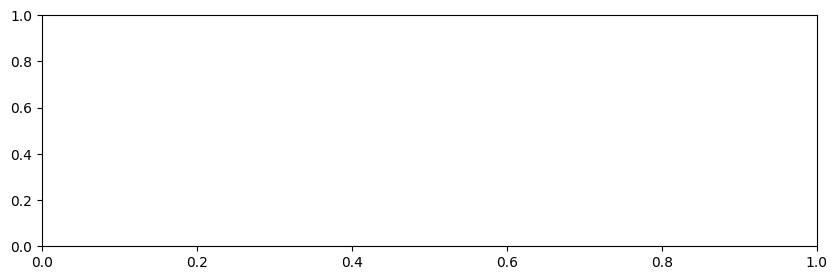

In [17]:
# Plot timeseries at the sample pixel (original vs extrapolated)
time_coord = data[TIME_DIM].values if TIME_DIM in data.coords else np.arange(arr.shape[0])
orig_ts = arr[:, iy, ix]
ex_ts = out_arr[:, iy, ix]
plt.figure(figsize=(10,3))
plt.plot(time_coord, orig_ts, label='original', linewidth=1.5)
plt.plot(time_coord, ex_ts, label='extrapolated', linewidth=1.2, linestyle='--')
plt.xlabel('time')
plt.ylabel(varname)
plt.title(f'Time series at pixel (iy={iy}, ix={ix})')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

/var/folders/6z/tqg0lf9108s22svs6qbs4d_80131yc/T/ipykernel_68843/4150112164.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


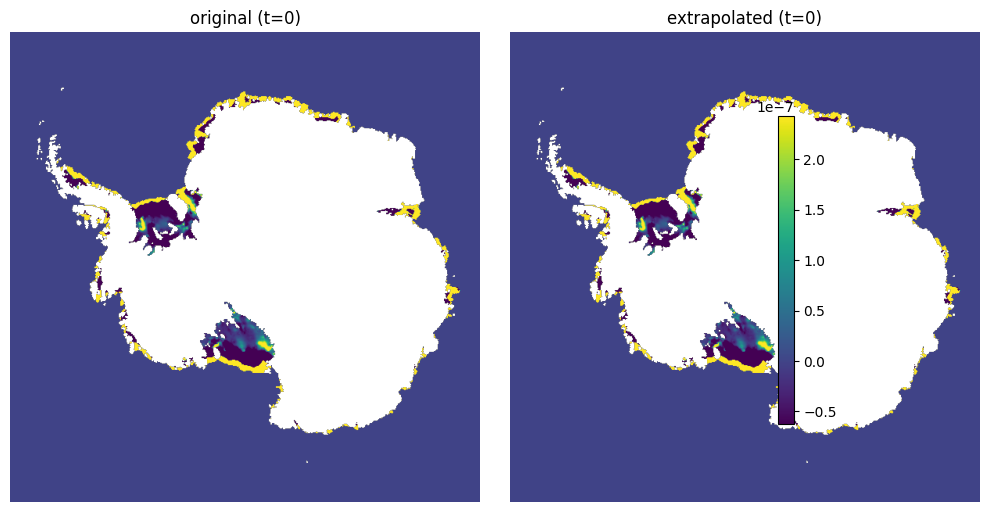

In [18]:
# Map comparison at a timeslice
t = min(PLOT_TIMESLICE_INDEX, arr.shape[0]-1)
orig_map = arr[t]
ex_map = out_arr[t]
vmin = np.nanpercentile(orig_map, 2)
vmax = np.nanpercentile(orig_map, 98)
fig, axs = plt.subplots(1,2, figsize=(10,5))
im0 = axs[0].imshow(orig_map, origin='lower', vmin=vmin, vmax=vmax)
axs[0].set_title('original (t={})'.format(t))
im1 = axs[1].imshow(ex_map, origin='lower', vmin=vmin, vmax=vmax)
axs[1].set_title('extrapolated (t={})'.format(t))
for ax in axs:
    ax.axis('off')
fig.colorbar(im1, ax=axs.ravel().tolist(), shrink=0.8)
plt.tight_layout()
plt.show()

## Notes and next steps

- This notebook uses a simple nearest-neighbor extrapolation via distance transform; it is fast and easy to reason about but may create sharp boundaries where data is scarce.
- If you want smoother extrapolation, replace `extrapolate_stack_nearest` with an interpolation or diffusion method (e.g., local thin-plate spline or iterative smoothing).
- For many shelves or large grids, consider coarsening (`COARSEN_FACTOR`) for quick tests then rerun full resolution once satisfied.
- I can add optional tapering, or an alternative `scipy.ndimage`-based inpainting, or a per-shelf report (counts filled per shelf) if you want more diagnostics.